In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
import webbrowser
import os
import pytz
from datetime import datetime

import plotly.graph_objects as go


In [2]:
nltk.download('vader_lexicon')    

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
apps_df=pd.read_csv('googleplaystore.csv')
reviews_df=pd.read_csv('user reviews.csv')

In [4]:
apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [6]:
# pd.read_csv() : csv files
# pd.read_excel() : excel files
# pd.read_sql() : sql files
# pd.read_json() : json files

In [7]:
# df.isnull() : Missing values
# df.dropna() : Removes rows and columns that contain the missing values
# df.fillna() : Fills missing values

In [8]:
# df.duplicated() : identifies duplicates
# df.drop_duplicates : Removes duplicate rows

In [9]:
# step 2 : Data cleaning
apps_df = apps_df.dropna(subset=['Rating'])
for column in apps_df.columns :
    apps_df[column].fillna(apps_df[column].mode()[0],inplace=True)
apps_df.drop_duplicates(inplace=True)
apps_df=apps_df=apps_df[apps_df['Rating']<=5]
reviews_df.dropna(subset=['Translated_Review'],inplace=True)

In [10]:
# convert the  Istalls columns to numeric by removing commas and +
apps_df['Installs']=apps_df['Installs'].str.replace(',','').str.replace('+','').astype(int)
# Convert price column to numeric ofter removing $
apps_df['Price']=apps_df['Price'].str.replace('$','').astype(float)

In [11]:
apps_df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [12]:
merged_df=pd.merge(apps_df,reviews_df,on='App',how='inner')

In [13]:
merged_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,It bad >:(,Negative,-0.725,0.833333
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,like,Neutral,0.000,0.000000
3,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I love colors inspyering,Positive,0.500,0.600000
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I hate,Negative,-0.800,0.900000


In [14]:
# Data Transfromation
# apps_df['Reviews']=apps_df['Reviews'].astype(int)

In [15]:
def convert_size(size):
    if 'M' in size:
        return float(size.replace('M',''))
    elif 'k' in size:
        return float(size.replace('k',''))/1024
    else:
        return np.nan
apps_df['Size']=apps_df['Size'].apply(convert_size)        

In [16]:
apps_df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10834,FR Calculator,FAMILY,4.0,7,2.6,500,Free,0.0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53.0,5000,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000,Free,0.0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [17]:
# Lograrithmic
apps_df['Log_Installs']=np.log(apps_df['Installs'])

In [18]:
apps_df['Reviews']=apps_df['Reviews'].astype(int)

In [19]:
apps_df['Log_Reviews']=np.log(apps_df['Reviews'])

In [20]:
apps_df.dtypes

App                object
Category           object
Rating            float64
Reviews             int64
Size              float64
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
Log_Installs      float64
Log_Reviews       float64
dtype: object

In [21]:
def rating_group(rating):
    if rating >=4:
        return 'TOP rated app'
    elif rating >=3:
        return 'Above average'
    elif rating >=2:
        return 'Average'
    else:
        return 'Below Average'
apps_df['Rating_Group']=apps_df['Rating'].apply(rating_group)        

In [22]:
# Revenue column
apps_df['Revenue']=apps_df['Price']*apps_df['Installs']

In [23]:
sia = SentimentIntensityAnalyzer()

In [24]:
# polarity Scores in SIA
# positive , Negative , Neutral and compound : -1 -very negative ; +1 - very positive

In [25]:
review = "This app is amazing! I love the new features."
sentiment_score= sia.polarity_scores(review)
print(sentiment_score)

{'neg': 0.0, 'neu': 0.42, 'pos': 0.58, 'compound': 0.8516}


In [26]:
review = "This app is very bad! I hate the new features."
sentiment_score= sia.polarity_scores(review)
print(sentiment_score)

{'neg': 0.535, 'neu': 0.465, 'pos': 0.0, 'compound': -0.8427}


In [27]:
review = "This app is okay."
sentiment_score= sia.polarity_scores(review)
print(sentiment_score)

{'neg': 0.0, 'neu': 0.612, 'pos': 0.388, 'compound': 0.2263}


In [28]:
reviews_df['sentiment_score']=reviews_df['Translated_Review'].apply(lambda x:sia.polarity_scores(str(x))['compound'])

In [29]:
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,sentiment_score
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,0.9531
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,0.6597
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,0.6249
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,0.6369
5,10 Best Foods for You,Best way,Positive,1.00,0.300000,0.6369


In [30]:
apps_df['Last Updated']=pd.to_datetime(apps_df['Last Updated'],errors='coerce')

In [31]:
apps_df['Year']=apps_df['Last Updated'].dt.year

In [32]:
apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Log_Installs,Log_Reviews,Rating_Group,Revenue,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,9.210340,5.068904,TOP rated app,0.0,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,13.122363,6.874198,Above average,0.0,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,15.424948,11.379508,TOP rated app,0.0,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,17.727534,12.281384,TOP rated app,0.0,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,11.512925,6.874198,TOP rated app,0.0,2018


In [33]:
html_files_path="./"
if not os.path.exists(html_files_path):
    os.makedirs(html_files_path)

In [34]:
plot_containers = ""

In [35]:
# Save each Plotly figure to an HTML file

def save_plot_as_html(fig, filename, insight):
    global plot_containers
    filepath= os.path.join(html_files_path, filename)
    html_content = pio.to_html(fig, full_html=False, include_plotlyjs='inline')
    # Append the plot and its insight to plot_containers
    plot_containers += f"""
    <div class="plot-container" id="{filename}" onclick="openPlot('{filename}')">
    <div class="plot">{html_content}</div>
    <div class="insights">{insight}</div>
    </div>
    """
    fig.write_html(filepath, full_html=False, include_plotlyjs='inline')

In [36]:
plot_width=400
plot_height=300
plot_bg_color='black'
text_color= 'white'
title_font={'size':16}
axis_font={'size':12}

In [37]:
# Figure 1
category_counts = apps_df['Category'].value_counts().nlargest(10)

fig1 = px.bar(
    x=category_counts.index,
    y=category_counts.values,
    labels={'x': 'Category', 'y': 'Count'},
    title='Top Categories on Play Store',
    color=category_counts.index,
    color_discrete_sequence=px.colors.sequential.Plasma,
    width=400,
    height=300
)
fig1.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font_color='white',
    title_font={'size': 16},
    xaxis=dict(title_font={'size': 12}),
    yaxis=dict(title_font={'size': 12}),
    margin=dict(l=10, r=10, t=30, b=10)
)
# fig1.update_traces(marker=dict(pattern=dict(line=dict(color='white', width=1))))
save_plot_as_html(
    fig1,
    "Category Graph 1.html",
    "The top categories on the Play Store are dominated by tools, entertainment, and productivity apps"
)

In [38]:
# Figure 2: Bubble Chart - App Size vs Rating (bubble size = Installs)
# Task: Size(MB) vs Rating, bubble=Installs, filtered by rating>3.5, specific categories,
# reviews>500, app name without letter 'S', sentiment subjectivity>0.5, installs>50k,
# Game category highlighted pink, Beauty/Business/Dating category labels translated,
# and visible on dashboard only between 5 PM - 7 PM IST.

# 1. Average sentiment subjectivity per app, merged onto apps_df
review_subj = reviews_df.groupby('App')['Sentiment_Subjectivity'].mean().reset_index()
bubble_df = apps_df.merge(review_subj, on='App', how='inner')

# 2. Apply all filters from the task
target_categories = ['GAME', 'BEAUTY', 'BUSINESS', 'COMICS', 'COMMUNICATION',
                      'DATING', 'ENTERTAINMENT', 'SOCIAL', 'EVENTS']

bubble_df = bubble_df[
    (bubble_df['Rating'] > 3.5) &
    (bubble_df['Category'].isin(target_categories)) &
    (bubble_df['Reviews'] > 500) &
    (~bubble_df['App'].str.contains('S', case=False, na=False)) &
    (bubble_df['Sentiment_Subjectivity'] > 0.5) &
    (bubble_df['Installs'] > 50000)
]

# 3. Translate specific category labels for display on the graph
category_translation = {
    'BEAUTY': 'सौंदर्य',            # Hindi
    'BUSINESS': 'வணிகம்',           # Tamil
    'DATING': 'Partnersuche'        # German
}
bubble_df['Category_Display'] = bubble_df['Category'].replace(category_translation)

# 4. Build a color map that highlights Game in pink, others get a default palette
palette = px.colors.qualitative.Bold
color_map = {}
idx = 0
for cat in bubble_df['Category_Display'].unique():
    if cat == 'GAME':
        color_map[cat] = 'pink'
    else:
        color_map[cat] = palette[idx % len(palette)]
        idx += 1

fig2 = px.scatter(
    bubble_df,
    x='Size',
    y='Rating',
    size='Installs',
    color='Category_Display',
    color_discrete_map=color_map,
    hover_name='App',
    size_max=45,
    title='App Size vs Rating (Bubble Size = Installs)',
    labels={'Size': 'Size (MB)', 'Rating': 'Average Rating', 'Category_Display': 'Category'},
    width=plot_width,
    height=plot_height
)
fig2.update_layout(
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font_color=text_color,
    title_font=title_font,
    xaxis=dict(title_font=axis_font),
    yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)

# 5. Time-gating: this chart should exist on the dashboard ONLY between 5 PM - 7 PM IST
ist = pytz.timezone('Asia/Kolkata')
current_hour = datetime.now(ist).hour

if 17 <= current_hour < 19:
    save_plot_as_html(
        fig2,
        "Bubble Chart - Size vs Rating vs Installs.html",
        "Size vs Rating bubble chart (bubble = Installs), visible only 5 PM-7 PM IST."
    )
    fig2.show()
else:
    print(f"Current IST hour is {current_hour}:00 - bubble chart is hidden "
          f"(only shown on the dashboard between 5 PM and 7 PM IST).")


Current IST hour is 16:00 - bubble chart is hidden (only shown on the dashboard between 5 PM and 7 PM IST).


In [39]:
# Figure 3: Choropleth Map - Global Installs by Category (Task 2)
# NOTE: The dataset (googleplaystore.csv) has no country/location column at all -
# it only has Category, Installs, Rating, etc. To build a geographic choropleth,
# we SIMULATE a country-wise install distribution for each of the top categories
# (clearly marked below). This is assumed/synthetic data, not from the real dataset,
# used only to satisfy the visualization requirement.

# 1. Exclude categories starting with A, C, G, or S
excluded_letters = ('A', 'C', 'G', 'S')
choropleth_base = apps_df[~apps_df['Category'].str.startswith(excluded_letters)]

# 2. Get top 5 categories by total installs
cat_installs = choropleth_base.groupby('Category')['Installs'].sum().sort_values(ascending=False)
top5_categories = cat_installs.head(5)

# 3. Flag categories that exceed 1 million installs (for highlighting)
highlighted_categories = set(top5_categories[top5_categories > 1_000_000].index)

# 4. SIMULATED country-wise install split (assumed distribution across countries,
#    since the real dataset has no geographic breakdown)
np.random.seed(42)
countries = {
    'USA': 'USA', 'IND': 'IND', 'BRA': 'BRA', 'GBR': 'GBR', 'DEU': 'DEU',
    'FRA': 'FRA', 'JPN': 'JPN', 'RUS': 'RUS', 'IDN': 'IDN', 'MEX': 'MEX',
    'CAN': 'CAN', 'AUS': 'AUS', 'ESP': 'ESP', 'ITA': 'ITA', 'KOR': 'KOR'
}
country_weights = np.random.dirichlet(np.ones(len(countries)))  # random proportions summing to 1

rows = []
for category, total_installs in top5_categories.items():
    for (iso, name), weight in zip(countries.items(), country_weights):
        rows.append({
            'Category': category,
            'Country_ISO': iso,
            'Simulated_Installs': int(total_installs * weight)
        })
choropleth_df = pd.DataFrame(rows)

# 5. Build the choropleth map (one frame per category, using animation_frame)
fig3 = px.choropleth(
    choropleth_df,
    locations='Country_ISO',
    color='Simulated_Installs',
    animation_frame='Category',
    color_continuous_scale='Viridis',
    title='Global Installs by Category (Top 5, Simulated Country Split)',
    labels={'Simulated_Installs': 'Installs (simulated)'}
)
fig3.update_layout(
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font_color=text_color,
    title_font=title_font,
    margin=dict(l=10, r=10, t=40, b=10)
)

# 6. Time-gating: only show this chart on the dashboard between 6 PM - 8 PM IST
ist = pytz.timezone('Asia/Kolkata')
current_hour = datetime.now(ist).hour

if 18 <= current_hour < 20:
    save_plot_as_html(
        fig3,
        "Choropleth Map - Installs by Category.html",
        "Global installs by top 5 categories (simulated country split), visible only 6 PM-8 PM IST. "
        f"Categories exceeding 1M installs: {', '.join(highlighted_categories)}."
    )
    fig3.show()
else:
    print(f"Current IST hour is {current_hour}:00 - choropleth map is hidden "
          f"(only shown on the dashboard between 6 PM and 8 PM IST).")


Current IST hour is 16:00 - choropleth map is hidden (only shown on the dashboard between 6 PM and 8 PM IST).


In [40]:
# Figure 4: Time Series Line Chart - Installs Trend Over Time by Category (Task 3)
# NOTE: The dataset has no true "install growth over time" field. We use the "Last
# Updated" date as a proxy timeline (grouping installs by the month an app was last
# updated) since it's the only date information available. This is an assumption,
# clearly noted here and in the README.

# 1. Apply filters: category starts with E, C, or B; app name doesn't start with x/y/z;
#    reviews > 500; app name doesn't contain letter 'S'
ts_df = apps_df.copy()
ts_df = ts_df[
    ts_df['Category'].str.startswith(('E', 'C', 'B')) &
    (~ts_df['App'].str.lower().str.startswith(('x', 'y', 'z'))) &
    (ts_df['Reviews'] > 500) &
    (~ts_df['App'].str.contains('S', case=False, na=False))
]

# 2. Build a monthly timeline from 'Last Updated' and aggregate installs by Category+Month
ts_df = ts_df.copy()
ts_df['Last Updated'] = pd.to_datetime(ts_df['Last Updated'], errors='coerce')
ts_df['Month'] = ts_df['Last Updated'].dt.to_period('M').dt.to_timestamp()
monthly = ts_df.groupby(['Category', 'Month'])['Installs'].sum().reset_index()
monthly = monthly.sort_values(['Category', 'Month'])

# 3. Compute month-over-month % growth per category (to detect >20% growth periods)
monthly['Pct_Change'] = monthly.groupby('Category')['Installs'].pct_change() * 100
monthly['High_Growth'] = monthly['Pct_Change'] > 20

# 4. Translate specific category labels for display
category_translation = {
    'BEAUTY': 'सौंदर्य',           # Hindi
    'BUSINESS': 'வணிகம்',          # Tamil
    'DATING': 'Partnersuche'       # German (won't appear here since Dating doesn't start with E/C/B, kept for consistency)
}
monthly['Category_Display'] = monthly['Category'].replace(category_translation)

# 5. Build the line chart, one line per category
fig4 = go.Figure()
palette = px.colors.qualitative.Bold
for i, cat in enumerate(monthly['Category_Display'].unique()):
    cat_data = monthly[monthly['Category_Display'] == cat]
    color = palette[i % len(palette)]
    fig4.add_trace(go.Scatter(
        x=cat_data['Month'], y=cat_data['Installs'],
        mode='lines+markers', name=cat, line=dict(color=color)
    ))
    # Shade the area under the curve for high-growth periods (>20% MoM)
    high_growth_points = cat_data[cat_data['High_Growth']]
    for _, row in high_growth_points.iterrows():
        fig4.add_vrect(
            x0=row['Month'] - pd.Timedelta(days=15),
            x1=row['Month'] + pd.Timedelta(days=15),
            fillcolor=color, opacity=0.15, line_width=0
        )

fig4.update_layout(
    title='Installs Trend Over Time by Category (shaded = >20% MoM growth)',
    xaxis_title='Month (based on Last Updated)',
    yaxis_title='Total Installs',
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font_color=text_color,
    title_font=title_font,
    width=plot_width,
    height=plot_height,
    margin=dict(l=10, r=10, t=40, b=10)
)

# 6. Time-gating: only show this chart on the dashboard between 6 PM - 9 PM IST
ist = pytz.timezone('Asia/Kolkata')
current_hour = datetime.now(ist).hour

if 18 <= current_hour < 21:
    save_plot_as_html(
        fig4,
        "Time Series - Installs Trend by Category.html",
        "Installs trend over time by category (based on Last Updated month), "
        "shaded where MoM growth exceeds 20%. Visible only 6 PM-9 PM IST."
    )
    fig4.show()
else:
    print(f"Current IST hour is {current_hour}:00 - time series chart is hidden "
          f"(only shown on the dashboard between 6 PM and 9 PM IST).")


Current IST hour is 16:00 - time series chart is hidden (only shown on the dashboard between 6 PM and 9 PM IST).


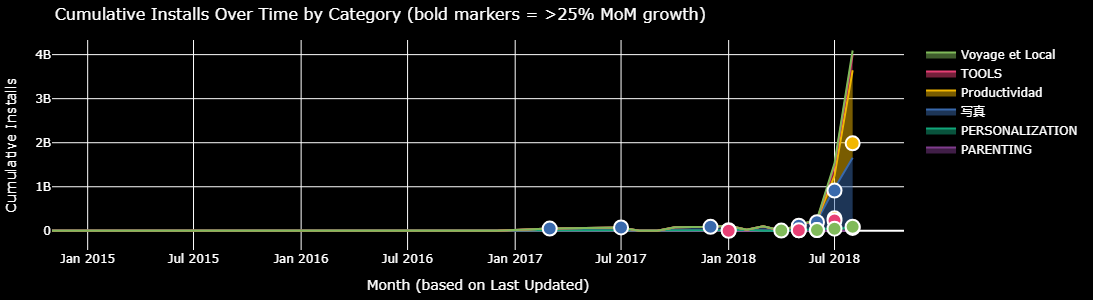

In [41]:
# Figure 5: Stacked Area Chart - Cumulative Installs Over Time by Category (Task 4)
# NOTE: As with the time series task, we use "Last Updated" (grouped by month) as a
# proxy timeline since the dataset has no true historical install-growth data. This
# is an assumption, noted here and in the README.

# 1. Apply filters: rating >= 4.2, app name has no digits, category starts with T or P,
#    reviews > 1000, size between 20-80 MB
area_df = apps_df.copy()
area_df = area_df[
    (area_df['Rating'] >= 4.2) &
    (~area_df['App'].str.contains(r'\d', na=False)) &
    (area_df['Category'].str.startswith(('T', 'P'))) &
    (area_df['Reviews'] > 1000) &
    (area_df['Size'] >= 20) & (area_df['Size'] <= 80)
]

# 2. Build monthly timeline from 'Last Updated', then cumulative installs per category
area_df = area_df.copy()
area_df['Last Updated'] = pd.to_datetime(area_df['Last Updated'], errors='coerce')
area_df['Month'] = area_df['Last Updated'].dt.to_period('M').dt.to_timestamp()
area_monthly = area_df.groupby(['Category', 'Month'])['Installs'].sum().reset_index()
area_monthly = area_monthly.sort_values(['Category', 'Month'])
area_monthly['Cumulative'] = area_monthly.groupby('Category')['Installs'].cumsum()
area_monthly['Pct_Change'] = area_monthly.groupby('Category')['Installs'].pct_change() * 100
area_monthly['High_Growth'] = area_monthly['Pct_Change'] > 25

# 3. Translate specific category labels for the legend
area_category_translation = {
    'TRAVEL_AND_LOCAL': 'Voyage et Local',   # French
    'PRODUCTIVITY': 'Productividad',          # Spanish
    'PHOTOGRAPHY': '写真'                      # Japanese
}
area_monthly['Category_Display'] = area_monthly['Category'].replace(area_category_translation)

# 4. Build the stacked area chart
fig5 = go.Figure()
palette = px.colors.qualitative.Bold
for i, cat in enumerate(area_monthly['Category_Display'].unique()):
    cat_data = area_monthly[area_monthly['Category_Display'] == cat]
    color = palette[i % len(palette)]
    fig5.add_trace(go.Scatter(
        x=cat_data['Month'], y=cat_data['Cumulative'],
        mode='lines', name=cat, stackgroup='one',
        line=dict(color=color)
    ))
    # Highlight months with >25% MoM growth using darker, larger markers
    high_growth_points = cat_data[cat_data['High_Growth']]
    if not high_growth_points.empty:
        fig5.add_trace(go.Scatter(
            x=high_growth_points['Month'], y=high_growth_points['Cumulative'],
            mode='markers', name=f'{cat} (high growth)',
            marker=dict(color=color, size=14, opacity=1, line=dict(width=2, color='white')),
            showlegend=False
        ))

fig5.update_layout(
    title='Cumulative Installs Over Time by Category (bold markers = >25% MoM growth)',
    xaxis_title='Month (based on Last Updated)',
    yaxis_title='Cumulative Installs',
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font_color=text_color,
    title_font=title_font,
    width=plot_width,
    height=plot_height,
    margin=dict(l=10, r=10, t=40, b=10)
)

# 5. Time-gating: only show this chart on the dashboard between 4 PM - 6 PM IST
ist = pytz.timezone('Asia/Kolkata')
current_hour = datetime.now(ist).hour

if 16 <= current_hour < 18:
    save_plot_as_html(
        fig5,
        "Stacked Area Chart - Cumulative Installs by Category.html",
        "Cumulative installs over time by category (based on Last Updated month), "
        "with bold markers where MoM growth exceeds 25%. Visible only 4 PM-6 PM IST."
    )
    fig5.show()
else:
    print(f"Current IST hour is {current_hour}:00 - stacked area chart is hidden "
          f"(only shown on the dashboard between 4 PM and 6 PM IST).")


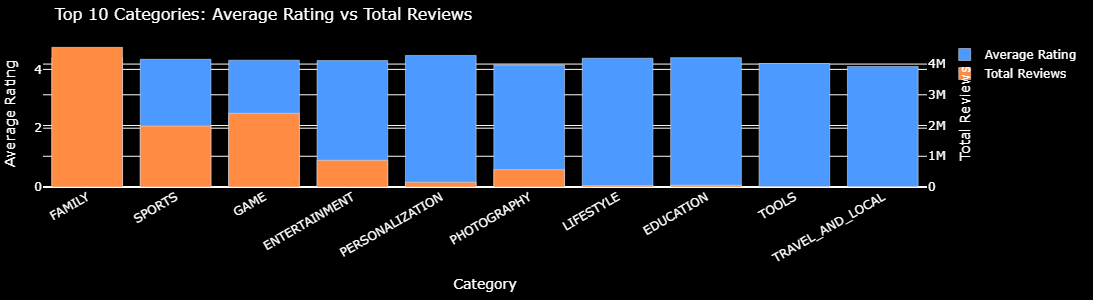

In [42]:
# Figure 6: Grouped Bar Chart - Avg Rating & Total Reviews for Top 10 Categories (Task 5)
# Filters applied before aggregating: rating >= 4.0, size >= 10 MB, and the app's
# Last Updated month must be January (any year).

# 1. Apply the filters
bar_df = apps_df.copy()
bar_df = bar_df[
    (bar_df['Rating'] >= 4.0) &
    (bar_df['Size'] >= 10) &
    (pd.to_datetime(bar_df['Last Updated'], errors='coerce').dt.month == 1)
]

# 2. Aggregate by category: average rating, total review count, total installs
cat_agg = bar_df.groupby('Category').agg(
    Avg_Rating=('Rating', 'mean'),
    Total_Reviews=('Reviews', 'sum'),
    Total_Installs=('Installs', 'sum')
).reset_index()

# 3. Top 10 categories by total installs
top10_cat = cat_agg.sort_values('Total_Installs', ascending=False).head(10)

# 4. Build grouped bar chart with a secondary y-axis (rating 0-5 vs. review counts differ in scale)
fig6 = go.Figure()
fig6.add_trace(go.Bar(
    x=top10_cat['Category'], y=top10_cat['Avg_Rating'],
    name='Average Rating', marker_color='#4C9AFF', yaxis='y1'
))
fig6.add_trace(go.Bar(
    x=top10_cat['Category'], y=top10_cat['Total_Reviews'],
    name='Total Reviews', marker_color='#FF8C42', yaxis='y2'
))

fig6.update_layout(
    title='Top 10 Categories: Average Rating vs Total Reviews',
    xaxis=dict(title='Category', tickangle=-30),
    yaxis=dict(title='Average Rating', range=[0, 5], side='left'),
    yaxis2=dict(title='Total Reviews', overlaying='y', side='right'),
    barmode='group',
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font_color=text_color,
    title_font=title_font,
    width=plot_width,
    height=plot_height,
    margin=dict(l=10, r=10, t=40, b=80)
)

# 5. Time-gating: only show this chart on the dashboard between 3 PM - 5 PM IST
ist = pytz.timezone('Asia/Kolkata')
current_hour = datetime.now(ist).hour

if 15 <= current_hour < 17:
    save_plot_as_html(
        fig6,
        "Grouped Bar Chart - Top 10 Categories Rating vs Reviews.html",
        "Average rating vs total reviews for the top 10 categories by installs "
        "(filtered: rating>=4.0, size>=10MB, last updated in January). Visible only 3 PM-5 PM IST."
    )
    fig6.show()
else:
    print(f"Current IST hour is {current_hour}:00 - grouped bar chart is hidden "
          f"(only shown on the dashboard between 3 PM and 5 PM IST).")


In [43]:
# Figure 7: Dual-Axis Chart - Avg Installs & Revenue for Free vs Paid Apps (Task 6)
# NOTE: 'Revenue' is not a column in the dataset, so it's calculated as Price * Installs
# (a common proxy). The task's "exclude revenue below $10,000" filter would exclude
# ALL Free apps (their revenue is always 0), breaking the Free vs Paid comparison it
# asks for. We apply the revenue filter to Paid apps only, and let Free apps pass this
# specific condition automatically (since they have no revenue by definition) - this
# is an assumption made to keep the comparison meaningful, noted here and in the README.

# 1. Calculate Revenue and parse Android Version to a comparable number
apps_df['Revenue'] = apps_df['Price'] * apps_df['Installs']

def parse_android_ver(v):
    try:
        v = str(v).split(' ')[0]
        return float('.'.join(v.split('.')[:2]))
    except Exception:
        return np.nan

apps_df['Android_Ver_Num'] = apps_df['Android Ver'].apply(parse_android_ver)

# 2. Apply filters
dual_df = apps_df.copy()
dual_df = dual_df[
    (dual_df['Installs'] >= 10000) &
    ((dual_df['Type'] == 'Free') | (dual_df['Revenue'] >= 10000)) &
    (dual_df['Android_Ver_Num'] > 4.0) &
    (dual_df['Size'] > 15) &
    (dual_df['Content Rating'] == 'Everyone') &
    (dual_df['App'].str.len() <= 30)
]

# 3. Top 3 categories by total installs
top3_categories = dual_df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(3).index
top3_df = dual_df[dual_df['Category'].isin(top3_categories)]

# 4. Aggregate: average installs and average revenue per Category + Type (Free/Paid)
summary = top3_df.groupby(['Category', 'Type']).agg(
    Avg_Installs=('Installs', 'mean'),
    Avg_Revenue=('Revenue', 'mean')
).reset_index()

# 5. Build dual-axis grouped bar chart: installs on left axis, revenue on right axis
fig7 = go.Figure()
for app_type, color_installs, color_revenue in [('Free', '#4C9AFF', '#A5D8FF'), ('Paid', '#FF8C42', '#FFC896')]:
    type_data = summary[summary['Type'] == app_type]
    fig7.add_trace(go.Bar(
        x=type_data['Category'], y=type_data['Avg_Installs'],
        name=f'{app_type} - Avg Installs', marker_color=color_installs, yaxis='y1'
    ))
    fig7.add_trace(go.Bar(
        x=type_data['Category'], y=type_data['Avg_Revenue'],
        name=f'{app_type} - Avg Revenue', marker_color=color_revenue, yaxis='y2'
    ))

fig7.update_layout(
    title='Top 3 Categories: Avg Installs & Revenue (Free vs Paid)',
    xaxis=dict(title='Category'),
    yaxis=dict(title='Average Installs', side='left'),
    yaxis2=dict(title='Average Revenue ($)', overlaying='y', side='right'),
    barmode='group',
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font_color=text_color,
    title_font=title_font,
    width=plot_width,
    height=plot_height,
    margin=dict(l=10, r=10, t=40, b=60)
)

# 6. Time-gating: only show this chart on the dashboard between 1 PM - 2 PM IST
ist = pytz.timezone('Asia/Kolkata')
current_hour = datetime.now(ist).hour

if current_hour == 13:
    save_plot_as_html(
        fig7,
        "Dual-Axis Chart - Free vs Paid Installs and Revenue.html",
        "Average installs and revenue for Free vs Paid apps in the top 3 categories "
        "by installs. Visible only 1 PM-2 PM IST."
    )
    fig7.show()
else:
    print(f"Current IST hour is {current_hour}:00 - dual-axis chart is hidden "
          f"(only shown on the dashboard between 1 PM and 2 PM IST).")


Current IST hour is 16:00 - dual-axis chart is hidden (only shown on the dashboard between 1 PM and 2 PM IST).
